# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Tomas Schmieder

**ID**: tas274

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [11]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/code/FALL 2025/BEE 4750/bee4750-hw1-tas274`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [5]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [13]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

### Problem 1.1 Write Up

The flaw in the problem was that the functioning was initializing the minimum value as zero.
This is incorrect because 0 is not a value within the array and all other values in the array are greater than zero.
To fix this flaw I changed it so that the minimum value in the array is just the first value, and then the checker works the same way to see if
the values in the array are less then the minimum value.

In [4]:
function minimum(array)
    # set minimum value to first element of array
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

### Problem 1.2 Write Up

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

`UndefVarError` means that the variable we are trying to use is not defined. 
We see that average_grade is what is not defined but this because it is being called inside the function. We also see that the function is not being called on and rather the average_grade is what is being called on. To fix this we can change the function to not have average_grade in it and rather use grades as the input variable for student_grades. Then we call on our functioning inputting student_grades and find the code to run smoothly.

In [ ]:
using Statistics # wasnt working without it (?)
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(grades)
  return average_grade
end
# call on the function using previously defined student_grades
average_grade = class_average(student_grades)

@show average_grade;

average_grade = 94.4


#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

### Problem 1.3 Write Up

What does this `MethodError` mean? Why does this code produce one? Fix the error and solve the problem.

A `MethodError` is when a function we called has arguments that don't match its existing argument definition. 
In our code we have n_trials defined as an integer, which Julia tries to call on, but its zero(n_trials), so it returns a zero and not a vector. We then try to index an integer in outcomes[i] which causes our `MethodError`. What we want is n_trials to be a vector to store the outcome of all of our trials not for it to be an integer.

To fix this what we can do is replace the zero(n_trials) as zeros(n_trials).

We also need to fix the (sum(passadieci()) > 11), as it should be at least 11 therefore needs to be >=.

In [3]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
# set the outcomes vector to be a vector of zeros
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) >= 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.479


#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

### Problem 1.4 Write Up

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

This `MethodError` occurs because we have vect - m as a vector while m is a scalar. We get the error because subtraction between a vector and a scalar isn't valid. 

To fix this we can change it so that the scalar is subtracted from each element of the vector by changing vect - m to vect .- m

In [16]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0.0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.41919142411294885, -0.04477120169153992, -0.15987063495003362, -0.3165390583665356, -0.04345183269168251, 0.4600428661267356, -0.4814808404373695, 0.05265958609672772, -0.019033198532207418, 0.11752715148103854, -0.2530763598508532, -0.3987461186978969, -0.4051668577883766, -0.14537708102382318, -0.021518846454485097, 0.2393846697392613, -0.13828803455335292, 0.28932439329980286, -0.44190436643288566, -0.41462031768210295, -0.1481768399620188, -0.4467685839176895, 0.16354702958537648, -0.324893449617489, -0.22436376824831783, 0.18691945805247367, -0.2843753736563317, 0.30832500598057266, 0.2757047181327851, 0.44059511305789445, 0.12832592230812423, 0.1935791502153814, 0.2896691235161918, -0.05389047441266104, 0.1218772930619838, -0.24482626621372394, 0.22316484875624798, 0.4597763846856109, -0.33758006386107464, 0.19126011359930628, -0.3305504301513418, -0.20836963537351572, 0.4435549655840101, 0.14379124696474477, 0.3902589386802747, -0.2551400209756388, 

1000-element Vector{Float64}:
  0.41919142411294885
 -0.04477120169153992
 -0.15987063495003362
 -0.3165390583665356
 -0.04345183269168251
  0.4600428661267356
 -0.4814808404373695
  0.05265958609672772
 -0.019033198532207418
  0.11752715148103854
  ⋮
  0.1701029484937252
 -0.45332724205642416
 -0.4743008238822817
 -0.4129715382326393
  0.23830378602543056
  0.06271140871181402
  0.11506229654060751
 -0.1638906511382653
 -0.0897920909169232

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

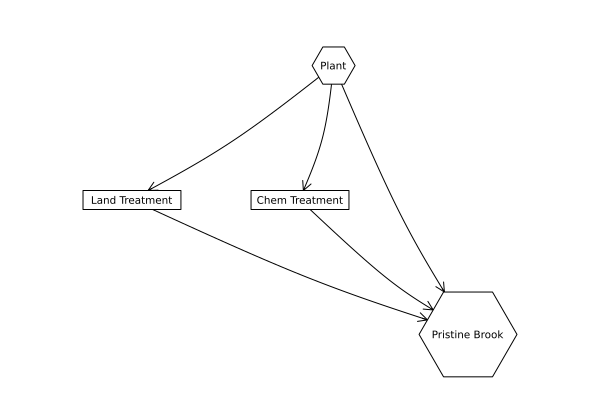

In [6]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => "", (1,3) => "", (1, 4) => "",(2, 4) => "",(3, 4) => "")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

### Problem 2.1 Write Up

We can imagine this problem as trying to find the most efficient model that finds the lowest treatmenet cost as well the lowest amount of YUK that will be discharged into Pristine Brook. We start by defining our known variables.

$$Q = 100~m^3/day~(\text{wastewater flow discharged into the brook})$$
$$\rho=1~kg/m^3~(\text{concentration of YUK in the wastewater})$$
$$S=20~kg/day~(\text{maximum amount of allowable YUK in the discharge to the brook})$$

Now lets define each of our two methods and their equations, for the land dispoal method, we have,
$$c_1=\frac{X_1^2}{20}~dollars/day$$
$$X_1~(m^3/day)~=~\text{amount of wastewater disposed to land disposal}$$
$$Z_{1}=(0.20)(\rho)(X_1)~kg/day,~\text{YUK mass to brook}$$
For the chemical treatment method we have,
$$c_2=1.50(X_2)~dollars/day$$
$$X_2~(m^3/day)~=~\text{amount of wastewater disposed to chemical treatment}$$
$$e=1-0.005(X_2),~\text{removal of YUK efficiency}$$
$$Z_{2}=(1-e)(\rho)(X_2)=0.005(X_2^2)~kg/day,~\text{YUK mass to brook}$$
For our normal direct discharge thats not being treated we have,
$$X_3~(m^3/day)~=~\text{amount of wastewater disposed to brook}$$
Our constraint of allowable YUK in the discharge to the brook can now be defined as,
$$Z=0.20(X_1)+0.005X_2^2+X_3\leq{S}=20$$
Our objective function is defined by the cost of each of the processes,
$$C(X_1,X_2,X_3)=\frac{X_1^2}{20}+1.50(X_2)$$
We also have two more constraints, one to ensure our flows add up to 100, and another to ensure no non negative flows
$$X_1+X_2+X_3=Q=100$$
$$X_1,X_2,X_3\geq{0}$$


Now with all of these pieces we have an optimization model that is ready to be implemented.


#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

### Problem 2.2 Write Up

To implement the model as a function I have done so below using what was defined above, in function form. 

In [16]:
function model(X1, X2, X3)
    Q = 100                 # flow
    r = 1                   # concentration
    S = 20                  # maximum amount of YUK
    @assert X1 >= 0 && X2 >= 0 && X3 >= 0               # no negative flows
    @assert isapprox(X1 + X2 + X3, Q; atol=1e-8)        #flows must sum to Q

    c1 = (X1^2)/20          # cost of land disposal
    c2 = 1.50 * X2          # cost of chemical treatment
    c = c1 + c2             # total cost

    z1 = 0.20 * r * X1      # land disposal discharge into brook
    z2 = 0.005 * r * X2^2   # chemical treatment discharge into brook
    z3 = r * X3             # direct discharge into brook
    z = z1 + z2 + z3        # total discharge

    feasible = z <= S       # check feasibility of solution
    return z, c, feasible
end

discharged, cost, feasible = model(60.0, 40.0, 0)         # test case where 60% of flow goes to land and 40% goes to chemical treatmnet
@show discharged cost feasible

discharged = 20.0
cost = 240.0
feasible = true


true

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

### Problem 2.3 Write Up

I set my code by first loading 3 packages, Distribution for the Dirichlet distribution, random for the rng seed, and plots for the plotting.
It starts by finding a random integer seed and initializing the RNG so the sampling is reproducible for that seed. We then set our flow as Q and n to 1000 for the number of combinations we look at.
It then uses the Diriclet package by creating a uniform distribution over n (1000) columns that are scaled by Q so that it follows that X1 + X2 + X3 = 100. X takes this form as a 3 x n (1000) matrix with rows of values of X1 X2 and X3. 
These values all then get put into the model that was created as part of problem 2.2. Then all of the results of each of the model runs are unpacked and plotted onto a graph. I also made it so that it prints the run that costed the least and also the run that released the least discharge (both of these under the effluent amount). 


Results for Lowest Cost Plan:
z = 19.681 kg/day
c = 264.72 dollar/day
Results for Lowest Discharge Plan:
z = 18.442 kg/day
c = 359.94 dollar/day
random seed = 10


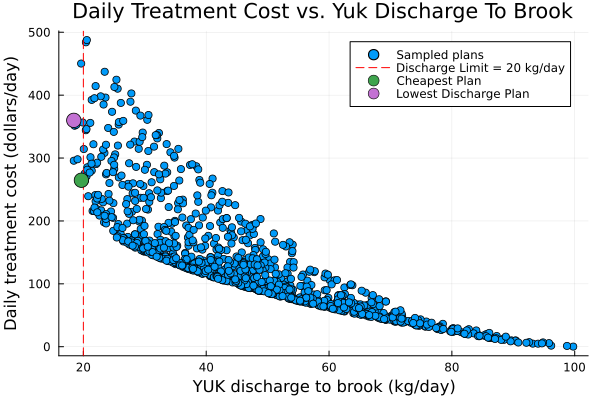

In [17]:
using Distributions, Random, Plots

# set random seed for data generation
seed = rand(1:100)
Random.seed!(seed)

Q = 100.0                       # flow
n = 1000                        # number of combinations

# vector whose elements sum to Q
d  = Dirichlet(ones(3))
# sample n from the Dirichlet distribution and scale by Q
X = Q .* rand(d, n)  

# results of each plans
results = [model(X[1,j], X[2,j], X[3,j]) for j in 1:n]

# unpack tuples into vectors
z = first.(results)                         # discharge
c = getindex.(results, 2)                   # cost
feasibility = getindex.(results, 3)         # feasibility

# summarize feasible set
feasible = findall(feasibility)

# print the results of the cehapest feasible plan
if !isempty(feasible)
    # find the cheapest feasible plan
    min_idxc = feasible[argmin(c[feasible])]
    println("Results for Lowest Cost Plan:")
    println("z = $(round(z[min_idxc], digits=3)) kg/day")
    println("c = $(round(c[min_idxc], digits=2)) dollar/day")
end

if !isempty(feasible)
    # find the lowest amount of yuk discharge
    min_idxz = feasible[argmin(z[feasible])]
    println("Results for Lowest Discharge Plan:")
    println("z = $(round(z[min_idxz], digits=3)) kg/day")
    println("c = $(round(c[min_idxz], digits=2)) dollar/day")
    
end

println("random seed = $seed")
# plot cost vs discharge
plt = scatter(z, c; xlabel = "YUK discharge to brook (kg/day)",
    ylabel = "Daily treatment cost (dollars/day)",
    title  = "Daily Treatment Cost vs. Yuk Discharge To Brook",
    label = "Sampled plans", legend = :topright)

# vertical line showing the maximum allowable discharge of 20
vline!(plt, [20.0]; lc = :red, ls = :dash, label = "Discharge Limit = 20 kg/day")

# highlight the cheapest feasible plan on the plot
if !isempty(feasible)
    scatter!(plt, [z[min_idxc]], [c[min_idxc]]; ms=8, label="Cheapest Plan")
    scatter!(plt, [z[min_idxz]], [c[min_idxz]]; ms=8, label="Lowest Discharge Plan")
end
# plot
display(plt)

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

### Problem 2.4 Write Up


To get the minimized cost point, I analytically solved the equation for effluent discharge $$Z=0.20(X_1)+0.005X_2^2+X_3\leq{S}=20$$ I found the two possible points for solutions that satisfied less then 20 effluent and then chose the one that cost the least. 

To get the point for the minimized discharge, I used the same equation simplified it down to just X2 and then found the derivative and set it to zero to see what at point would the minimum value be. The math can be seen in the screenshot below.

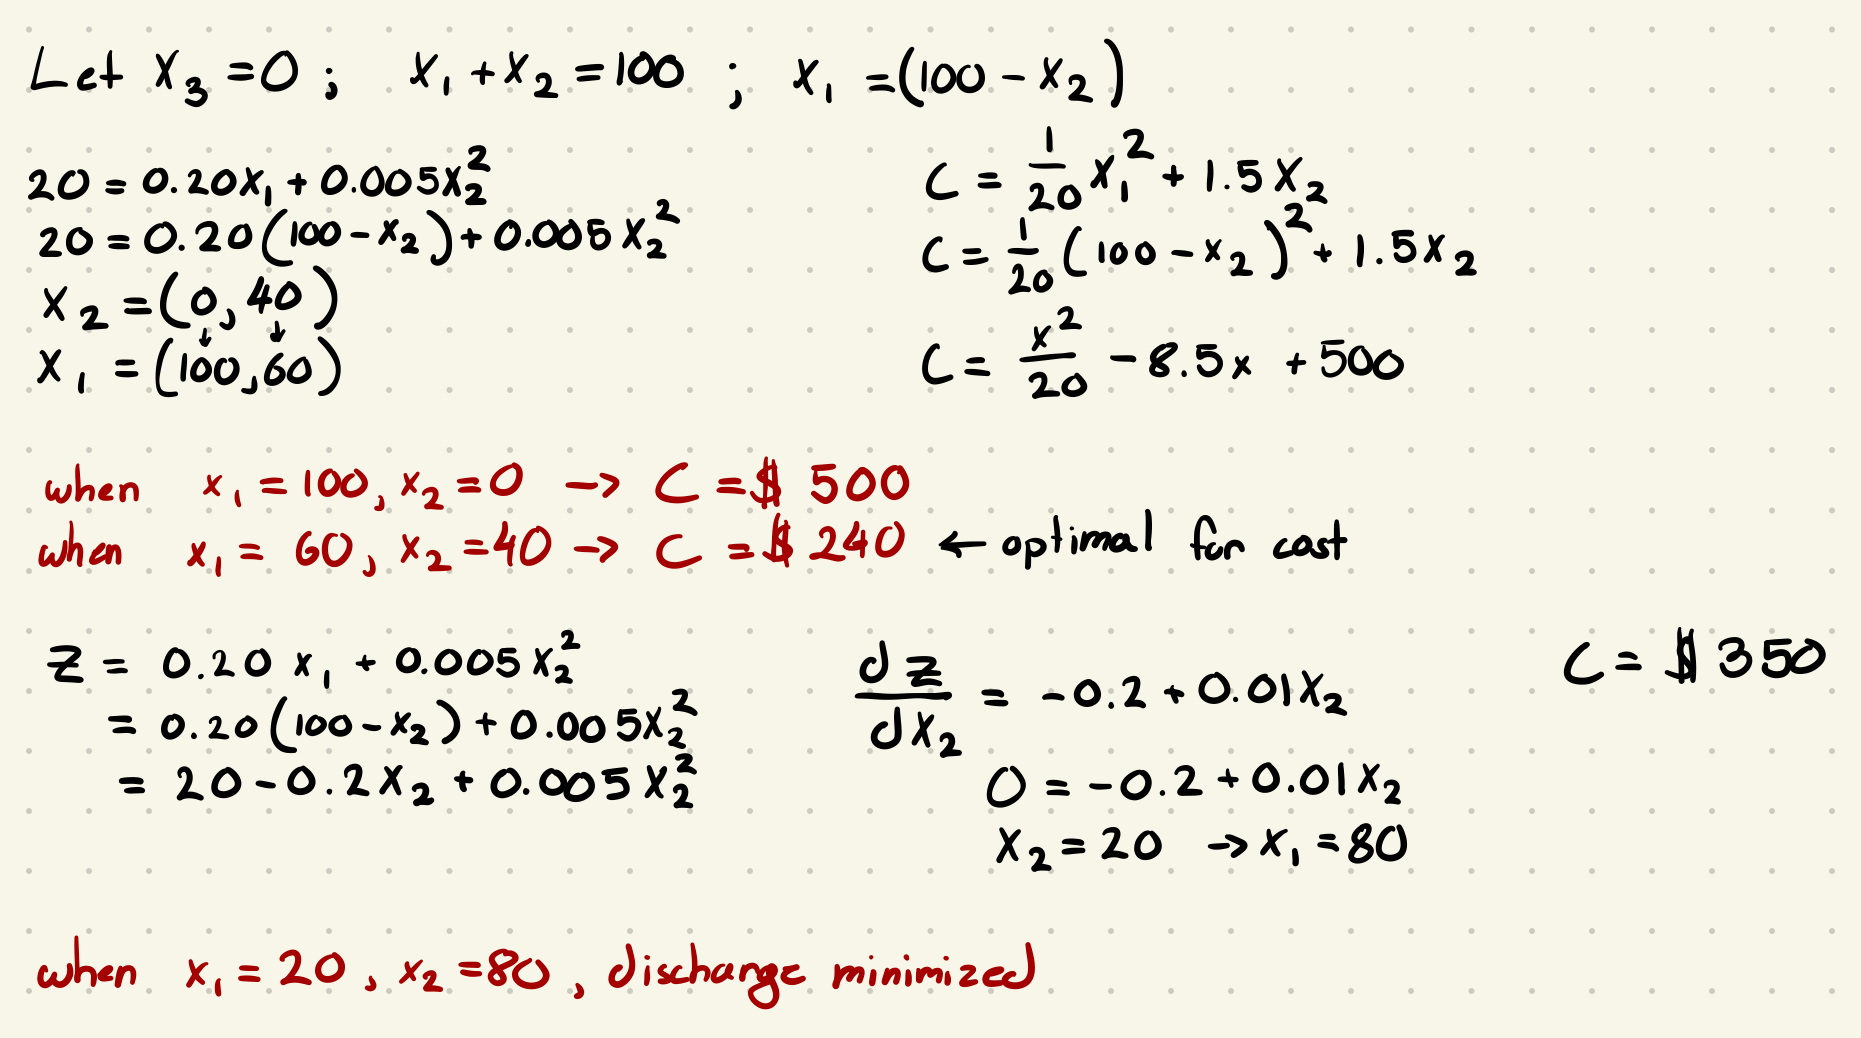


Comparing these values to the ones that were spread out on the plot the values are similar to the numerical answers that were found as the cheapest/minimized feasible plans. 

Now if I were to choose a plan from my entire set it would be probably be one of these two fully optimized plans, but since they are optimized for different goals it would depend on what I want, do I want the cheaper plan or do I want the plan that discharges the least? Most likely the cheapest plan.  


The code here is relatively the same, I just added the two points that were found analytically onto the plot. Also do note, that another even cheaper plan would be just letting all the discharge go to X3 since it costs nothing to discharge straight to the stream, but that would obviously mean the effluent levels exceed 20 so I did not choose to calculate or use that plan.

random seed = 98


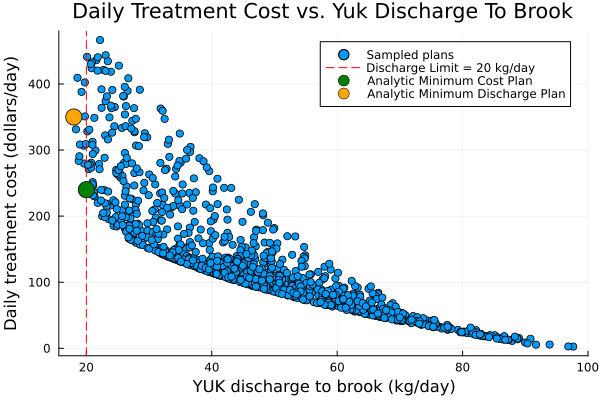

In [18]:
using Distributions, Random, Plots

# set random seed for data generation
seed = rand(1:100)
Random.seed!(seed)

Q = 100.0                       # flow
n = 1000                        # number of combinations

# vector whose elements sum to Q
d  = Dirichlet(ones(3))
# sample n from the Dirichlet distribution and scale by Q
X = Q .* rand(d, n)  

# results of each plans
results = [model(X[1,j], X[2,j], X[3,j]) for j in 1:n]

# unpack tuples into vectors
z = first.(results)                         # discharge
c = getindex.(results, 2)                   # cost
feasibility = getindex.(results, 3)         # feasibility

# summarize feasible set
feasible = findall(feasibility)
println("random seed = $seed")

# plot cost vs discharge
plt = scatter(z, c; xlabel = "YUK discharge to brook (kg/day)",
    ylabel = "Daily treatment cost (dollars/day)",
    title  = "Daily Treatment Cost vs. Yuk Discharge To Brook",
    label = "Sampled plans", legend = :topright)

# vertical line showing the maximum allowable discharge of 20
vline!(plt, [20.0]; lc = :red, ls = :dash, label = "Discharge Limit = 20 kg/day")

# add analytical points
scatter!(plt, [20.0], [240.0]; ms=9, c=:green,label="Analytic Minimum Cost Plan")
scatter!(plt, [18.0], [350.0];ms=9, c=:orange, label="Analytic Minimum Discharge Plan")

# plot
display(plt)


## References

List any external references consulted, including classmates.

Stack Overflow and Julia documentation